# Binary Classification Mini-Project

Dataset setup for the Breast Cancer Wisconsin (Diagnostic) binary classification task.

## Dataset and Train-Test Split

We use `sklearn.datasets.load_breast_cancer`, which contains 569 samples with 30 real-valued features derived from digitised FNA biopsy images. The original sklearn target uses `0 = malignant` and `1 = benign`, so we remap it to match the assignment convention: `1 = malignant` and `0 = benign`.

All experiments use an 80/20 stratified train-test split with `random_state=42`.

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

In [2]:
breast_cancer = load_breast_cancer()

X = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names,
)

# sklearn encodes malignant as 0 and benign as 1. The assignment expects
# malignant = 1 and benign = 0, so invert the sklearn target.
y = pd.Series(1 - breast_cancer.target, name="malignant")

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("Class counts:")
print(y.value_counts().sort_index().rename(index={0: "benign", 1: "malignant"}))
# print breast_cancer 3 rows with feature names and target values
print("\nSample data:")
print(pd.concat([X, y], axis=1).head(3))

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Class counts:
malignant
benign       357
malignant    212
Name: count, dtype: int64

Sample data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 455 samples
Test set: 114 samples


In [4]:
split_summary = pd.DataFrame(
    {
        "train_count": y_train.value_counts().sort_index(),
        "train_fraction": y_train.value_counts(normalize=True).sort_index(),
        "test_count": y_test.value_counts().sort_index(),
        "test_fraction": y_test.value_counts(normalize=True).sort_index(),
    }
).rename(index={0: "benign", 1: "malignant"})

split_summary

,train_count,train_fraction,test_count,test_fraction
malignant,,,,
benign,285,0.626374,72,0.631579
malignant,170,0.373626,42,0.368421


## L2-Regularised Logistic Regression

We fit logistic regression with L2 regularisation. The inverse regularisation strength `C` is selected using 5-fold stratified cross-validation on the training set only. Features are standardised inside the pipeline before fitting so that coefficient magnitudes are comparable across features.

In [5]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

C_GRID = np.logspace(-4, 4, 17)

l2_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=C_GRID,
        cv=5,
        penalty="l2",
        scoring="accuracy",
        solver="lbfgs",
        max_iter=10_000,
        random_state=RANDOM_STATE,
    ),
)

l2_logreg.fit(X_train, y_train)

logreg_model = l2_logreg.named_steps["logisticregressioncv"]
best_c = float(logreg_model.C_[0])
coefficients = pd.Series(
    logreg_model.coef_.ravel(),
    index=X_train.columns,
    name="coefficient",
)

coefficient_table = coefficients.to_frame()
coefficient_table["abs_coefficient"] = coefficient_table["coefficient"].abs()
coefficient_table = coefficient_table.sort_values("abs_coefficient", ascending=False)

top_five_features = coefficient_table.head(5)

print(f"Best C from 5-fold CV: {best_c:g}")
print("\nLearned coefficient vector (standardised feature scale):")
print(coefficients.to_string())
print("\nFive most influential features by |w_j|:")
print(top_five_features)


Best C from 5-fold CV: 3.16228

Learned coefficient vector (standardised feature scale):
mean radius                0.163365
mean texture               0.302134
mean perimeter             0.182990
mean area                  0.384127
mean smoothness            0.501305
mean compactness          -1.091155
mean concavity             1.165834
mean concave points        1.472044
mean symmetry             -0.405945
mean fractal dimension     0.282763
radius error               2.050871
texture error             -0.837988
perimeter error            1.098838
area error                 1.505861
smoothness error           0.414698
compactness error         -1.377701
concavity error           -0.393278
concave points error       0.960949
symmetry error            -0.664072
fractal dimension error   -0.807286
worst radius               1.147324
worst texture              2.192046
worst perimeter            0.824763
worst area                 1.276103
worst smoothness           0.187897
worst compa

## Class-Conditional Gaussian Models: LDA vs QDA

We fit Gaussian class-conditional models by maximum likelihood on the training set. LDA uses one shared covariance matrix across the two classes, while QDA estimates a separate covariance matrix for each class. The reported training log-likelihood is the labelled joint log-likelihood, $\sum_i \log p(y_i) + \log p(x_i \mid y_i)$, using maximum-likelihood class priors, means, and covariance matrices.

In [6]:
import warnings

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from scipy.linalg import LinAlgWarning


def mle_class_priors(y, classes):
    y_array = np.asarray(y)
    return np.array([(y_array == cls).mean() for cls in classes])


def mle_class_means(X, y, classes):
    X_array = np.asarray(X, dtype=float)
    y_array = np.asarray(y)
    return np.vstack([X_array[y_array == cls].mean(axis=0) for cls in classes])


def mle_covariances(X, y, classes, means, shared):
    X_array = np.asarray(X, dtype=float)
    y_array = np.asarray(y)

    if shared:
        scatter = np.zeros((X_array.shape[1], X_array.shape[1]))
        for class_index, cls in enumerate(classes):
            centered = X_array[y_array == cls] - means[class_index]
            scatter += centered.T @ centered
        return scatter / X_array.shape[0]

    covariances = []
    for class_index, cls in enumerate(classes):
        centered = X_array[y_array == cls] - means[class_index]
        covariances.append(centered.T @ centered / centered.shape[0])
    return covariances


def gaussian_logpdf(X, mean, covariance):
    X_array = np.asarray(X, dtype=float)
    covariance = np.asarray(covariance, dtype=float)
    sign, logdet = np.linalg.slogdet(covariance)
    if sign <= 0:
        covariance = covariance + 1e-8 * np.eye(covariance.shape[0])
        sign, logdet = np.linalg.slogdet(covariance)

    centered = X_array - mean
    solved = np.linalg.solve(covariance, centered.T).T
    quadratic_form = np.sum(centered * solved, axis=1)
    n_features = X_array.shape[1]
    return -0.5 * (n_features * np.log(2 * np.pi) + logdet + quadratic_form)


def labelled_gaussian_log_likelihood(X, y, classes, priors, means, covariances, shared):
    X_array = np.asarray(X, dtype=float)
    y_array = np.asarray(y)
    total = 0.0

    for class_index, cls in enumerate(classes):
        class_mask = y_array == cls
        covariance = covariances if shared else covariances[class_index]
        total += np.sum(
            np.log(priors[class_index])
            + gaussian_logpdf(X_array[class_mask], means[class_index], covariance)
        )

    return float(total)


lda = LinearDiscriminantAnalysis(solver="lsqr", store_covariance=True)
qda = QuadraticDiscriminantAnalysis(store_covariance=True)

lda.fit(X_train, y_train)
with warnings.catch_warnings(record=True) as qda_warnings:
    warnings.simplefilter("always", LinAlgWarning)
    qda.fit(X_train, y_train)

classes = lda.classes_
priors = mle_class_priors(y_train, classes)
means = mle_class_means(X_train, y_train, classes)
lda_covariance = mle_covariances(X_train, y_train, classes, means, shared=True)
qda_covariances = mle_covariances(X_train, y_train, classes, means, shared=False)

lda_log_likelihood = labelled_gaussian_log_likelihood(
    X_train,
    y_train,
    classes,
    priors,
    means,
    lda_covariance,
    shared=True,
)
qda_log_likelihood = labelled_gaussian_log_likelihood(
    X_train,
    y_train,
    classes,
    priors,
    means,
    qda_covariances,
    shared=False,
)

log_likelihood_summary = pd.DataFrame(
    {
        "model": ["LDA", "QDA"],
        "covariance_assumption": ["shared covariance", "class-specific covariances"],
        "n_covariance_matrices": [1, len(classes)],
        "training_log_likelihood": [lda_log_likelihood, qda_log_likelihood],
    }
)

print(log_likelihood_summary.to_string(index=False))

if qda_log_likelihood > lda_log_likelihood:
    better_model = "QDA"
    reason = "it estimates a separate covariance matrix for each class, making the Gaussian model more flexible."
else:
    better_model = "LDA"
    reason = "the shared-covariance constraint gives the higher likelihood on this training split."

print(f"\nHigher training log-likelihood: {better_model}, because {reason}")
print(
    "This is an in-sample likelihood comparison: QDA's extra covariance parameters can improve "
    "training fit, but they also increase variance and overfitting risk."
)

if qda_warnings:
    print(
        "QDA also raised a covariance rank warning, which is plausible for this dataset because "
        "several features are strongly correlated; this makes the unregularised covariance estimates ill-conditioned."
    )


model      covariance_assumption  n_covariance_matrices  training_log_likelihood
  LDA          shared covariance                      1             14820.462741
  QDA class-specific covariances                      2             18067.407400

Higher training log-likelihood: QDA, because it estimates a separate covariance matrix for each class, making the Gaussian model more flexible.
This is an in-sample likelihood comparison: QDA's extra covariance parameters can improve training fit, but they also increase variance and overfitting risk.
QDA also raised a covariance rank warning, which is plausible for this dataset because several features are strongly correlated; this makes the unregularised covariance estimates ill-conditioned.


## Support Vector Machines

We train two SVM variants: a linear-kernel SVM and an RBF-kernel SVM. Hyperparameters are selected using 5-fold grid search on the training set. For visualisation, the training data are standardised and projected onto the first two principal components; support vectors selected by each fitted SVM are highlighted in that 2-D PCA plane.

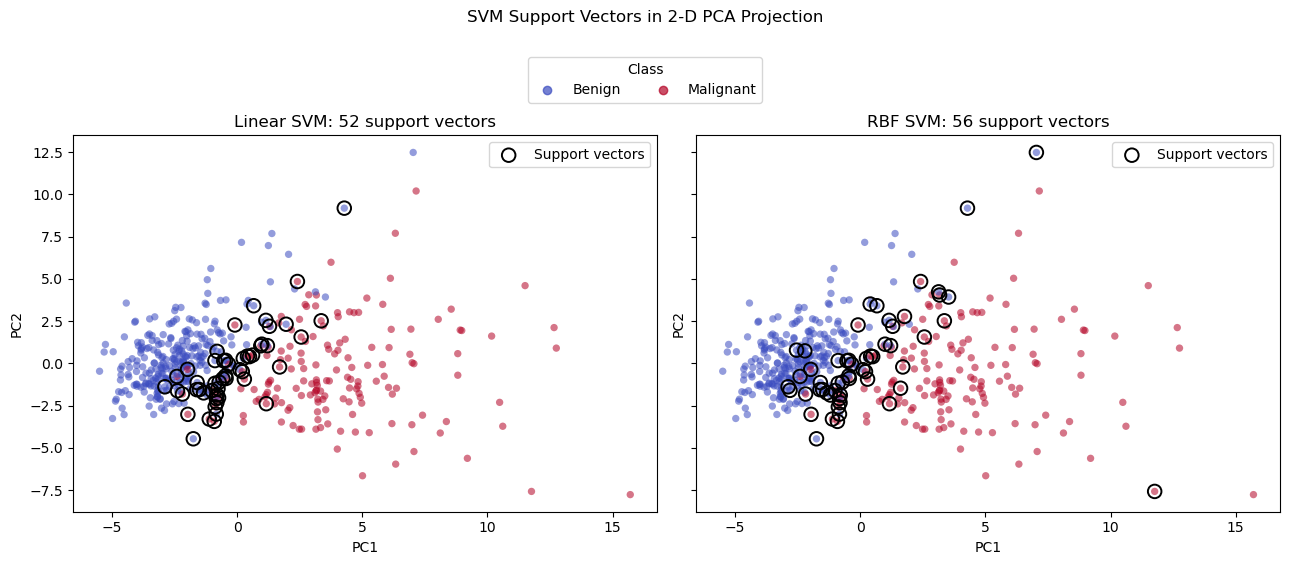

SVM grid-search summary:
kernel                          best_params  best_cv_accuracy  n_support_vectors  support_vectors_class_0  support_vectors_class_1
linear                      {'svc__C': 0.1}          0.967033                 52                       26                       26
   rbf {'svc__C': 10.0, 'svc__gamma': 0.01}          0.975824                 56                       29                       27

PCA explained variance ratio: PC1=0.446, PC2=0.185


In [7]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

linear_svm_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), SVC(kernel="linear")),
    param_grid={"svc__C": np.logspace(-3, 3, 7)},
    cv=svm_cv,
    scoring="accuracy",
)

rbf_svm_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), SVC(kernel="rbf")),
    param_grid={
        "svc__C": np.logspace(-3, 3, 7),
        "svc__gamma": np.logspace(-4, 1, 6),
    },
    cv=svm_cv,
    scoring="accuracy",
)

linear_svm_grid.fit(X_train, y_train)
rbf_svm_grid.fit(X_train, y_train)

linear_svm = linear_svm_grid.best_estimator_.named_steps["svc"]
rbf_svm = rbf_svm_grid.best_estimator_.named_steps["svc"]

svm_summary = pd.DataFrame(
    {
        "kernel": ["linear", "rbf"],
        "best_params": [linear_svm_grid.best_params_, rbf_svm_grid.best_params_],
        "best_cv_accuracy": [linear_svm_grid.best_score_, rbf_svm_grid.best_score_],
        "n_support_vectors": [linear_svm.support_.size, rbf_svm.support_.size],
        "support_vectors_class_0": [linear_svm.n_support_[0], rbf_svm.n_support_[0]],
        "support_vectors_class_1": [linear_svm.n_support_[1], rbf_svm.n_support_[1]],
    }
)

pca_scaler = StandardScaler()
X_train_scaled = pca_scaler.fit_transform(X_train)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca_2d.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
svm_models = [
    ("Linear SVM", linear_svm),
    ("RBF SVM", rbf_svm),
]

for ax, (title, model) in zip(axes, svm_models):
    scatter = ax.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=y_train,
        cmap="coolwarm",
        alpha=0.55,
        s=28,
        edgecolors="none",
    )
    support_indices = model.support_
    ax.scatter(
        X_train_pca[support_indices, 0],
        X_train_pca[support_indices, 1],
        facecolors="none",
        edgecolors="black",
        s=95,
        linewidths=1.4,
        label="Support vectors",
    )
    ax.set_title(f"{title}: {support_indices.size} support vectors")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

handles, labels = scatter.legend_elements(prop="colors", alpha=0.7)
fig.legend(
    handles,
    ["Benign", "Malignant"],
    title="Class",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.04),
)
fig.suptitle("SVM Support Vectors in 2-D PCA Projection", y=1.12)
fig.tight_layout()
plt.show()

print("SVM grid-search summary:")
print(svm_summary.to_string(index=False))
print(
    f"\nPCA explained variance ratio: PC1={pca_2d.explained_variance_ratio_[0]:.3f}, "
    f"PC2={pca_2d.explained_variance_ratio_[1]:.3f}"
)
